# Overview of the Project

To better understand and compare the performance of different machine learning models, we create visualizations based on the evaluation metrics obtained earlier. These plots provide a clear and intuitive way to assess how each model performs across key metrics such as accuracy, precision, recall, and F1-score.

First, the evaluation results stored in a dictionary are converted into a structured DataFrame, making it easier to analyze and visualize the data.

Next, bar charts are generated to compare the models. A combined plot displays all performance metrics in a single figure, allowing for an overall comparison. In addition, individual plots for each metric (accuracy, precision, recall, and F1-score) are created to provide a more detailed view of model performance.

These visualizations help identify the best-performing model and highlight the trade-offs between different evaluation metrics. They play an important role in selecting the most suitable model for further optimization and potential deployment in the liver cancer prediction system.

In [1]:
# importing the necessary libries 
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import math
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif
# Handling outliers by capping 
from scipy.stats import mstats
# libries 
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


In [2]:
df = pd.read_csv(r"C:\Users\lamin\OneDrive\Desktop\Datafolder\synthetic_liver_cancer_dataset.csv")

In [3]:
df.head() # Take a look of the data

,age,gender,bmi,alcohol_consumption,smoking_status,hepatitis_b,hepatitis_c,liver_function_score,alpha_fetoprotein_level,cirrhosis_history,family_history_cancer,physical_activity_level,diabetes,liver_cancer
0,68,Female,18.1,Regular,Former,0,0,51.9,16.44,0,0,Low,0,0
1,81,Female,19.9,Occasional,Never,0,0,41.6,8.09,0,0,Moderate,1,0
2,58,Female,25.5,Never,Never,0,0,76.0,0.64,0,0,Moderate,0,0
3,44,Male,16.0,Never,Former,0,0,50.3,19.09,0,0,Low,1,0
4,72,Male,21.0,Occasional,Former,0,0,39.5,4.95,1,0,Low,1,1


In [4]:
# changing categorical columns to numeric (Label Encoding)
# Gender
df['gender'] = df['gender'].map({'Female': 0, 'Male': 1})

# Alcohol consumption
df['alcohol_consumption'] = df['alcohol_consumption'].map({
    'Never': 0,
    'Occasional': 1,
    'Regular': 2
})

# Smoking status
df['smoking_status'] = df['smoking_status'].map({
    'Never': 0,
    'Former': 1,
    'Current': 2
})

# Physical activity
df['physical_activity_level'] = df['physical_activity_level'].map({
    'Low': 0,
    'Moderate': 1,
    'High': 2
})

# Descriptive Statistic of the data


In [5]:
# checking for missing values
df.isnull().sum() # the dataset is clean no missing value

age                        0
gender                     0
bmi                        0
alcohol_consumption        0
smoking_status             0
hepatitis_b                0
hepatitis_c                0
liver_function_score       0
alpha_fetoprotein_level    0
cirrhosis_history          0
family_history_cancer      0
physical_activity_level    0
diabetes                   0
liver_cancer               0
dtype: int64

In [6]:
# checking for the key metrics of the data
df.describe()

,age,gender,bmi,alcohol_consumption,smoking_status,hepatitis_b,hepatitis_c,liver_function_score,alpha_fetoprotein_level,cirrhosis_history,family_history_cancer,physical_activity_level,diabetes,liver_cancer
count,5000.000000,5000.000000,5000.00000,5000.000000,5000.000000,5000.00000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,57.222800,0.498800,25.90464,0.801000,0.723600,0.15120,0.095800,65.203900,15.109424,0.301600,0.241400,0.811800,0.199200,0.217800
std,15.799224,0.500049,5.10520,0.753069,0.781105,0.35828,0.294346,14.875477,15.196809,0.458998,0.427975,0.747859,0.399439,0.412792
min,30.000000,0.000000,8.10000,0.000000,0.000000,0.00000,0.000000,5.500000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,44.000000,0.000000,22.50000,0.000000,0.000000,0.00000,0.000000,54.800000,4.357500,0.000000,0.000000,0.000000,0.000000,0.000000
50%,57.000000,0.000000,25.90000,1.000000,1.000000,0.00000,0.000000,65.200000,10.340000,0.000000,0.000000,1.000000,0.000000,0.000000
75%,71.000000,1.000000,29.30000,1.000000,1.000000,0.00000,0.000000,75.200000,21.010000,1.000000,0.000000,1.000000,0.000000,0.000000
max,84.000000,1.000000,43.70000,2.000000,2.000000,1.00000,1.000000,115.700000,136.800000,1.000000,1.000000,2.000000,1.000000,1.000000


In [7]:
correlation = df['liver_cancer'].corr(df['family_history_cancer']) # checking for the correlation between two feautures

correlation

0.23225515834157648

In [8]:
# check for the data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   age                      5000 non-null   int64  
 1   gender                   5000 non-null   int64  
 2   bmi                      5000 non-null   float64
 3   alcohol_consumption      5000 non-null   int64  
 4   smoking_status           5000 non-null   int64  
 5   hepatitis_b              5000 non-null   int64  
 6   hepatitis_c              5000 non-null   int64  
 7   liver_function_score     5000 non-null   float64
 8   alpha_fetoprotein_level  5000 non-null   float64
 9   cirrhosis_history        5000 non-null   int64  
 10  family_history_cancer    5000 non-null   int64  
 11  physical_activity_level  5000 non-null   int64  
 12  diabetes                 5000 non-null   int64  
 13  liver_cancer             5000 non-null   int64  
dtypes: float64(3), int64(11)

# Data Visualization 

C:\Users\lamin\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


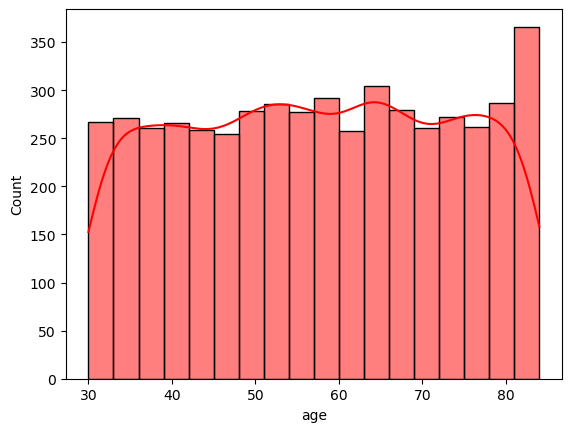

In [9]:
sns.histplot(df['age'], kde = True , color = 'red')
plt.show()

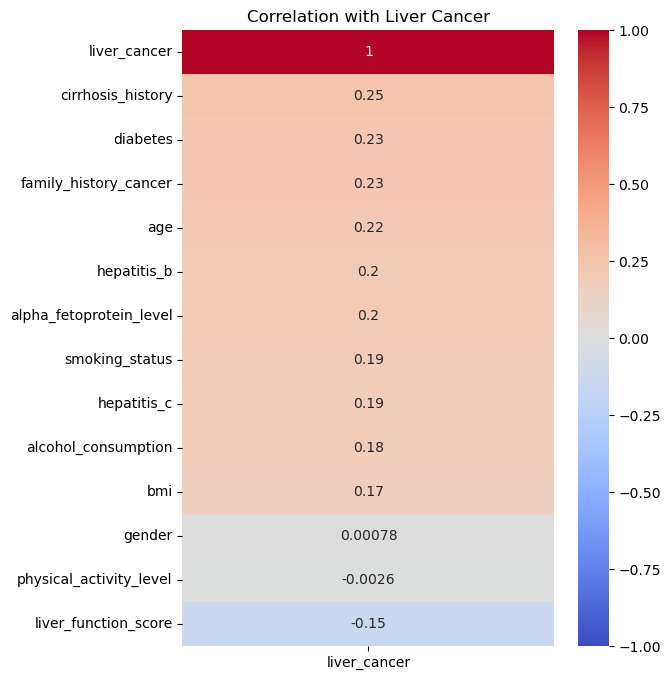

In [10]:
# visualizing the correlation
corr_target = df.corr()['liver_cancer'].sort_values(ascending=False)

plt.figure(figsize=(6,8))
sns.heatmap(corr_target.to_frame(), 
            annot=True, 
            cmap='coolwarm', 
            vmin=-1, vmax=1)

plt.title("Correlation with Liver Cancer")
plt.show()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   age                      5000 non-null   int64  
 1   gender                   5000 non-null   int64  
 2   bmi                      5000 non-null   float64
 3   alcohol_consumption      5000 non-null   int64  
 4   smoking_status           5000 non-null   int64  
 5   hepatitis_b              5000 non-null   int64  
 6   hepatitis_c              5000 non-null   int64  
 7   liver_function_score     5000 non-null   float64
 8   alpha_fetoprotein_level  5000 non-null   float64
 9   cirrhosis_history        5000 non-null   int64  
 10  family_history_cancer    5000 non-null   int64  
 11  physical_activity_level  5000 non-null   int64  
 12  diabetes                 5000 non-null   int64  
 13  liver_cancer             5000 non-null   int64  
dtypes: float64(3), int64(11)

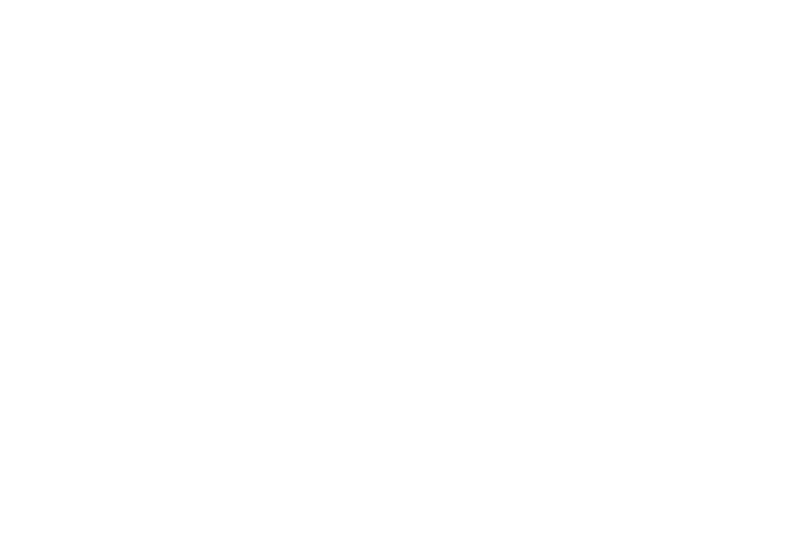

In [11]:
# Step 1: Data Overview
fig, ax = plt.subplots(1, 1, figsize=(10, 6))
data_info = df.info(buf=None)  # Get data structure information
ax.axis('off')  # Turn off axis as we don't need to plot the info
ax.text(0.5, 0.5, "Data Overview:\n\n" + str(data_info), ha='center', va='center', fontsize=12, color="white")
plt.suptitle("Step 1: Data Overview", fontsize=14, color="white")
plt.show()

C:\Users\lamin\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\lamin\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\lamin\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\lamin\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating

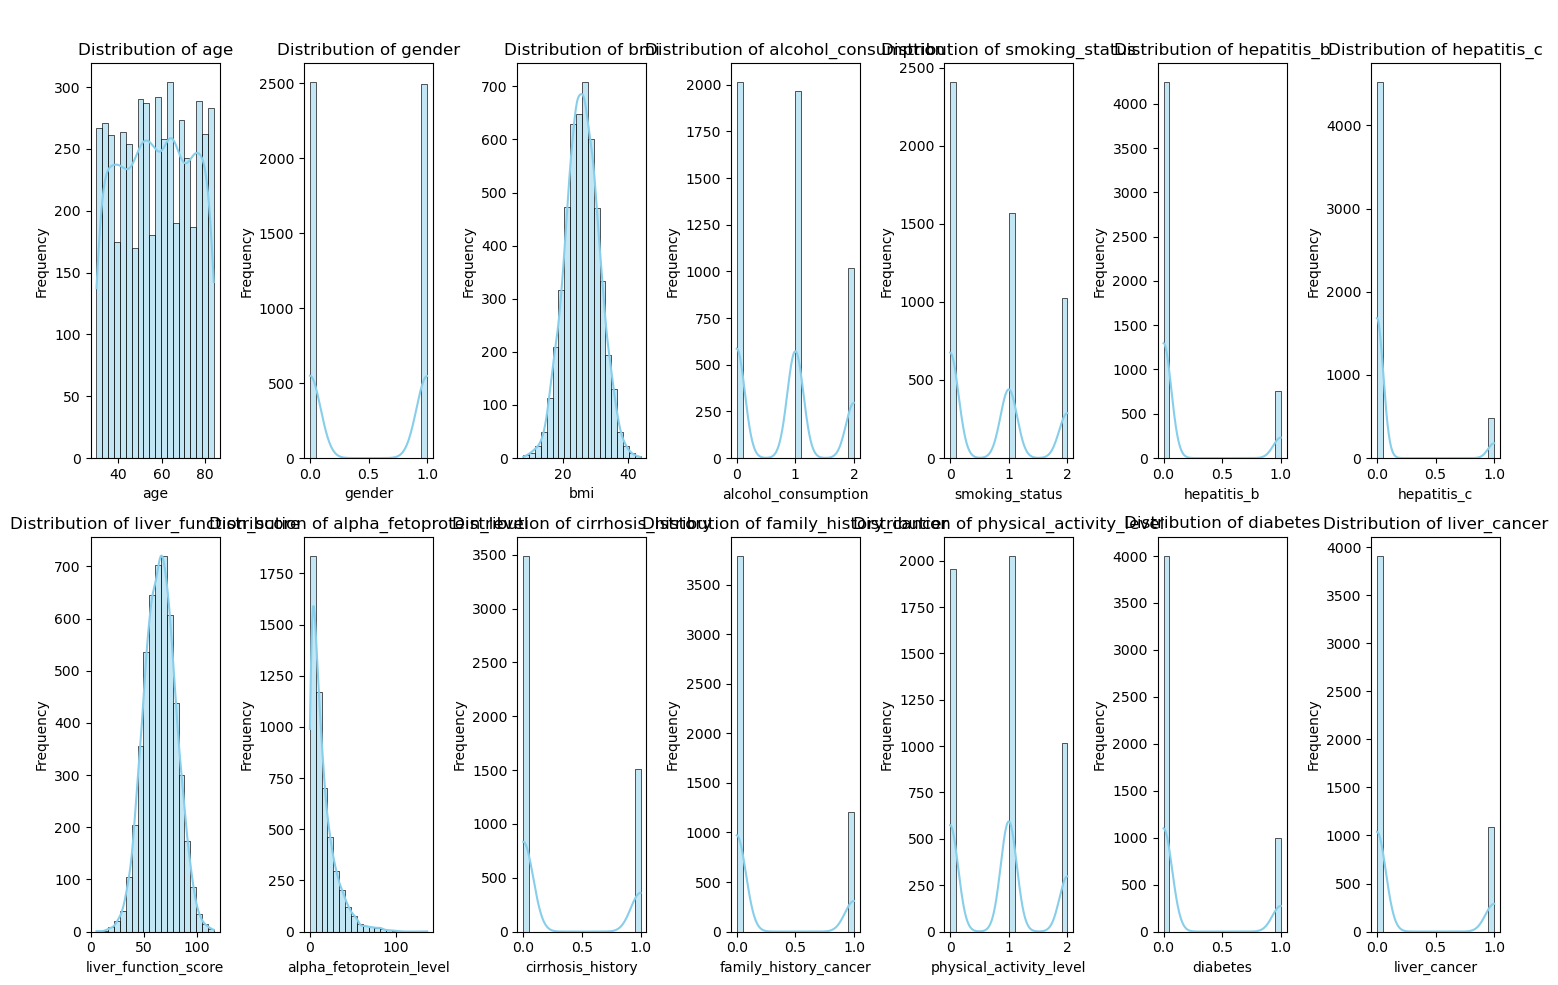

In [12]:
# Step 2: Univariate Analysis (Distributions)
numerical_cols = df.select_dtypes(include=[np.number]).columns
fig, axes = plt.subplots(2, len(numerical_cols)//2, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    sns.histplot(df[col], kde=True, color="skyblue", bins=20, ax=axes[i])
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')

plt.suptitle("Step 2: Univariate Analysis (Distributions)", fontsize=16, color="white")
plt.tight_layout()
plt.show()

C:\Users\lamin\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\lamin\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\lamin\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\lamin\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating

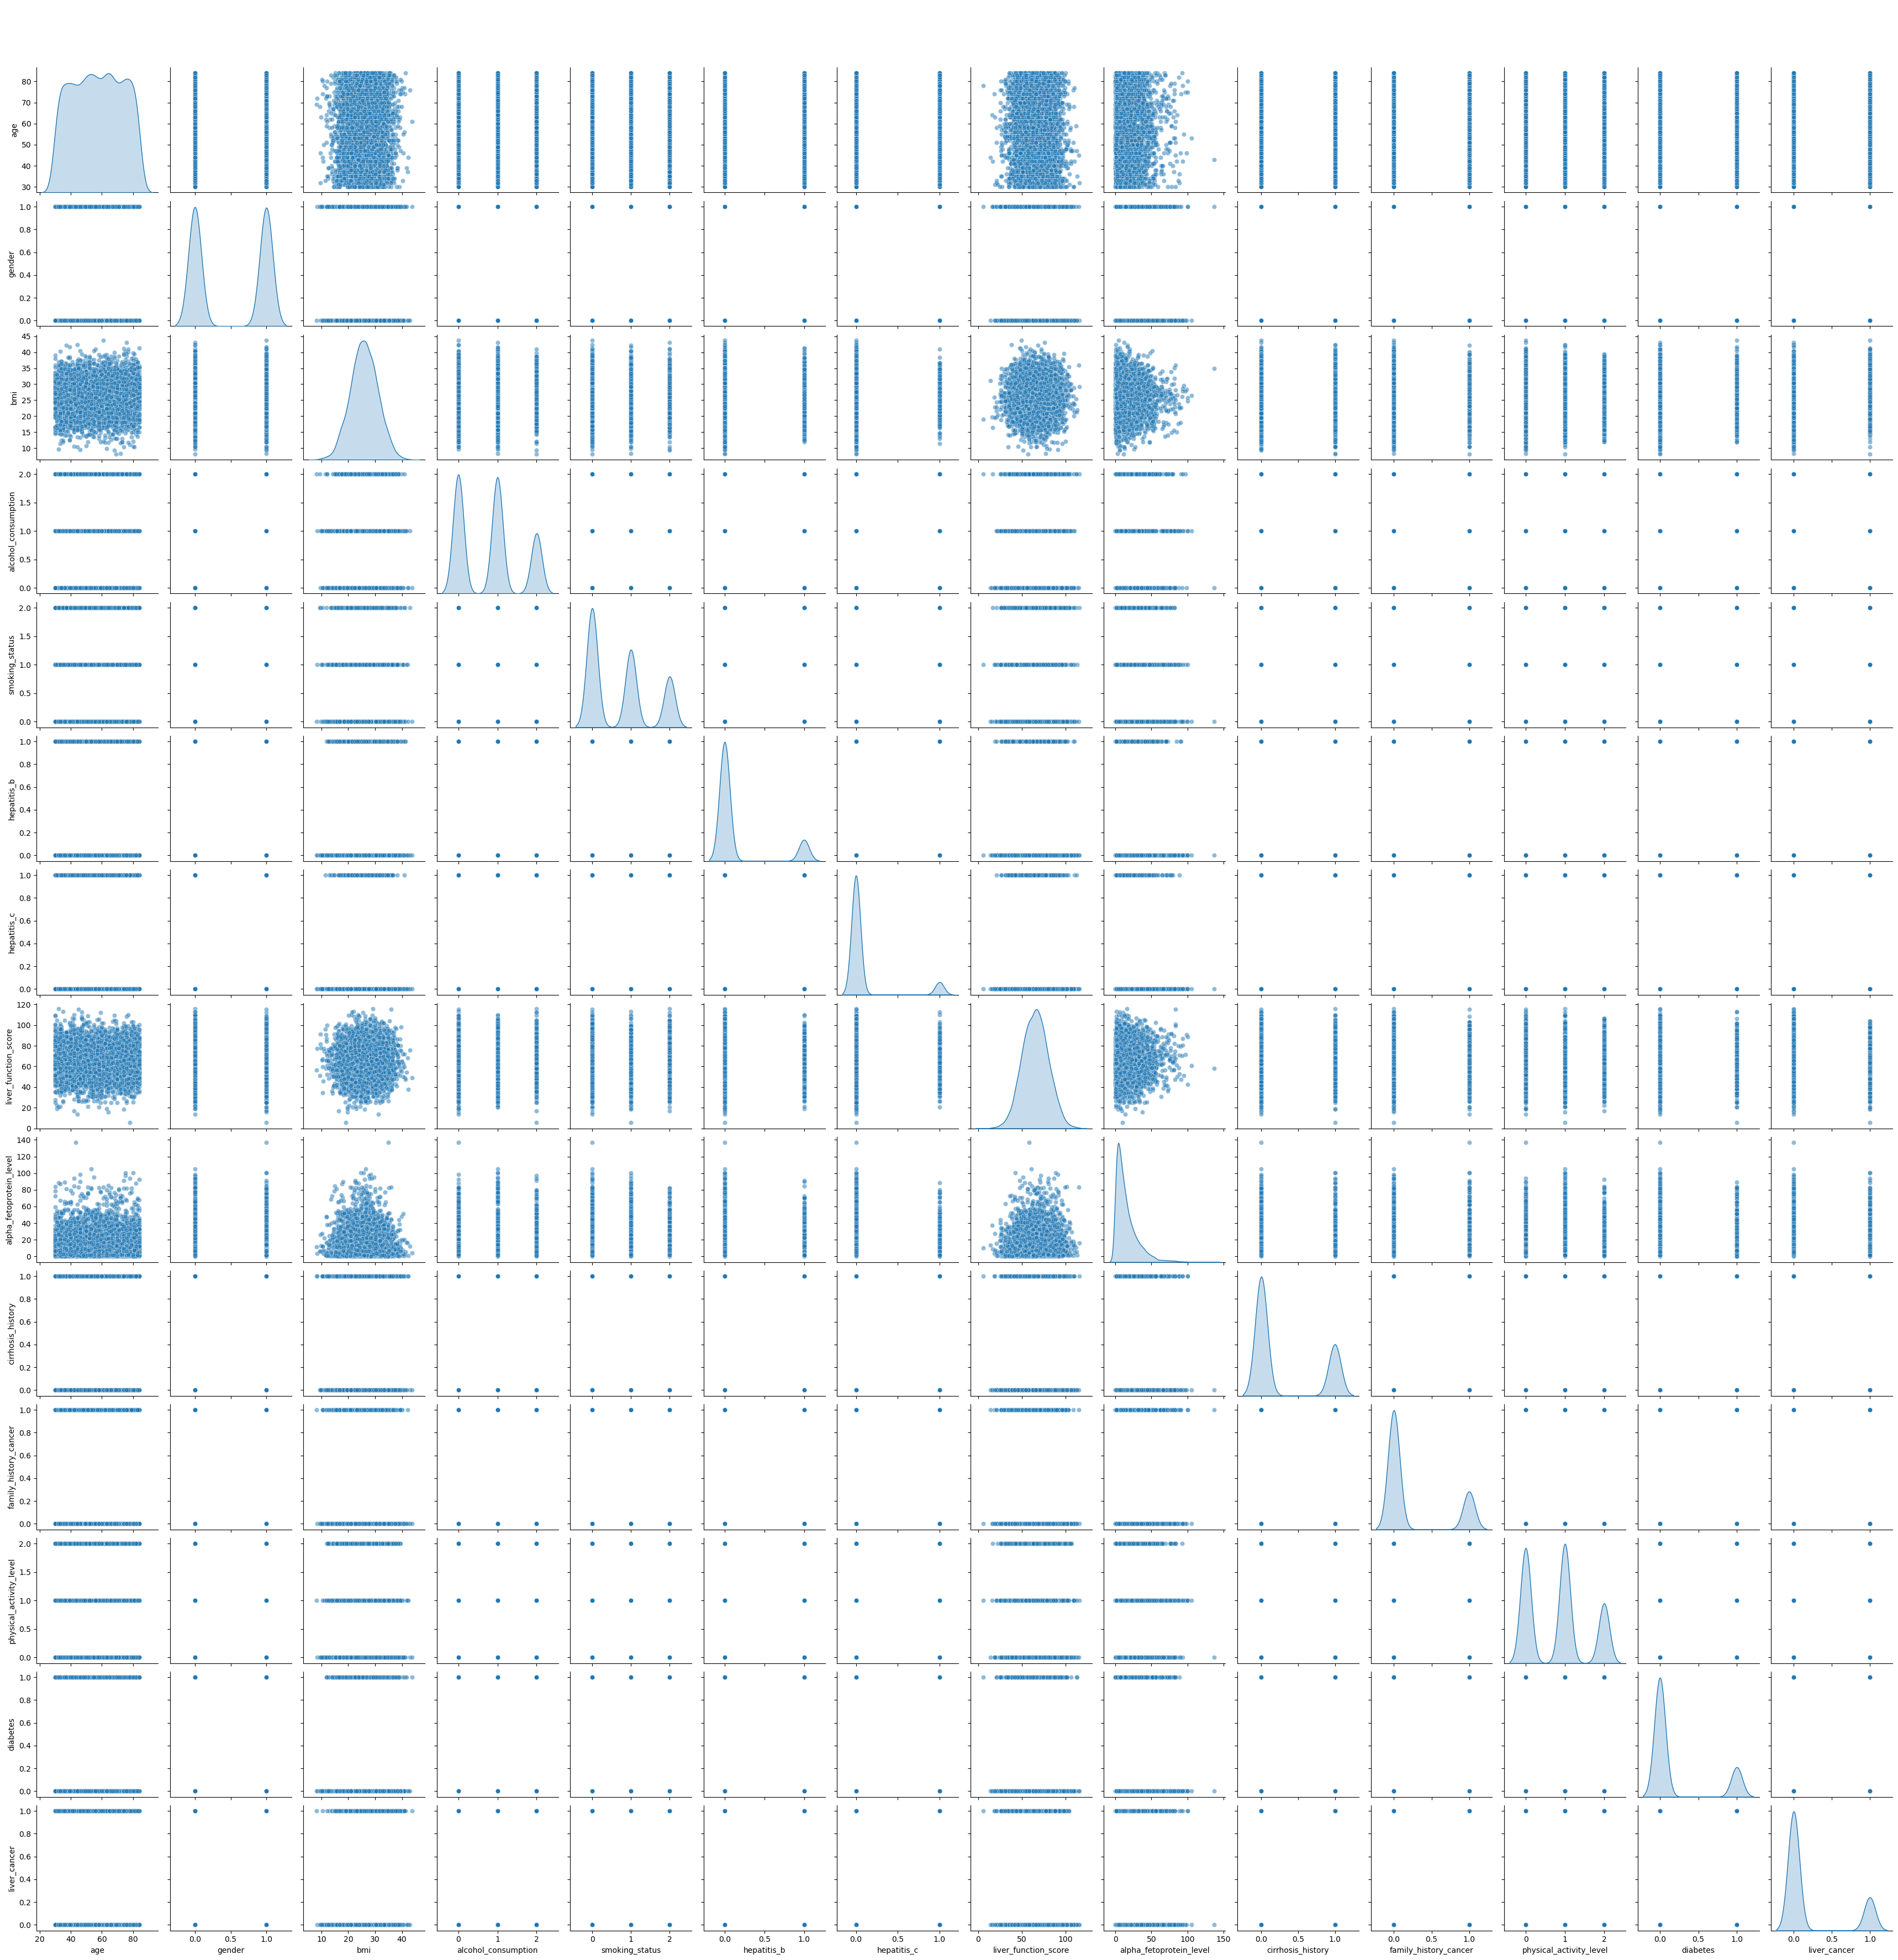

In [13]:
# Step 5: Feature Relationships (Pairplot and Heatmap)
# Pairplot for numerical features
sns.pairplot(df[numerical_cols], diag_kind='kde', plot_kws={'alpha':0.5})
plt.suptitle("Step 5: Pair Plot of Numerical Features", y=1.02, fontsize=16, color="white")
plt.show()


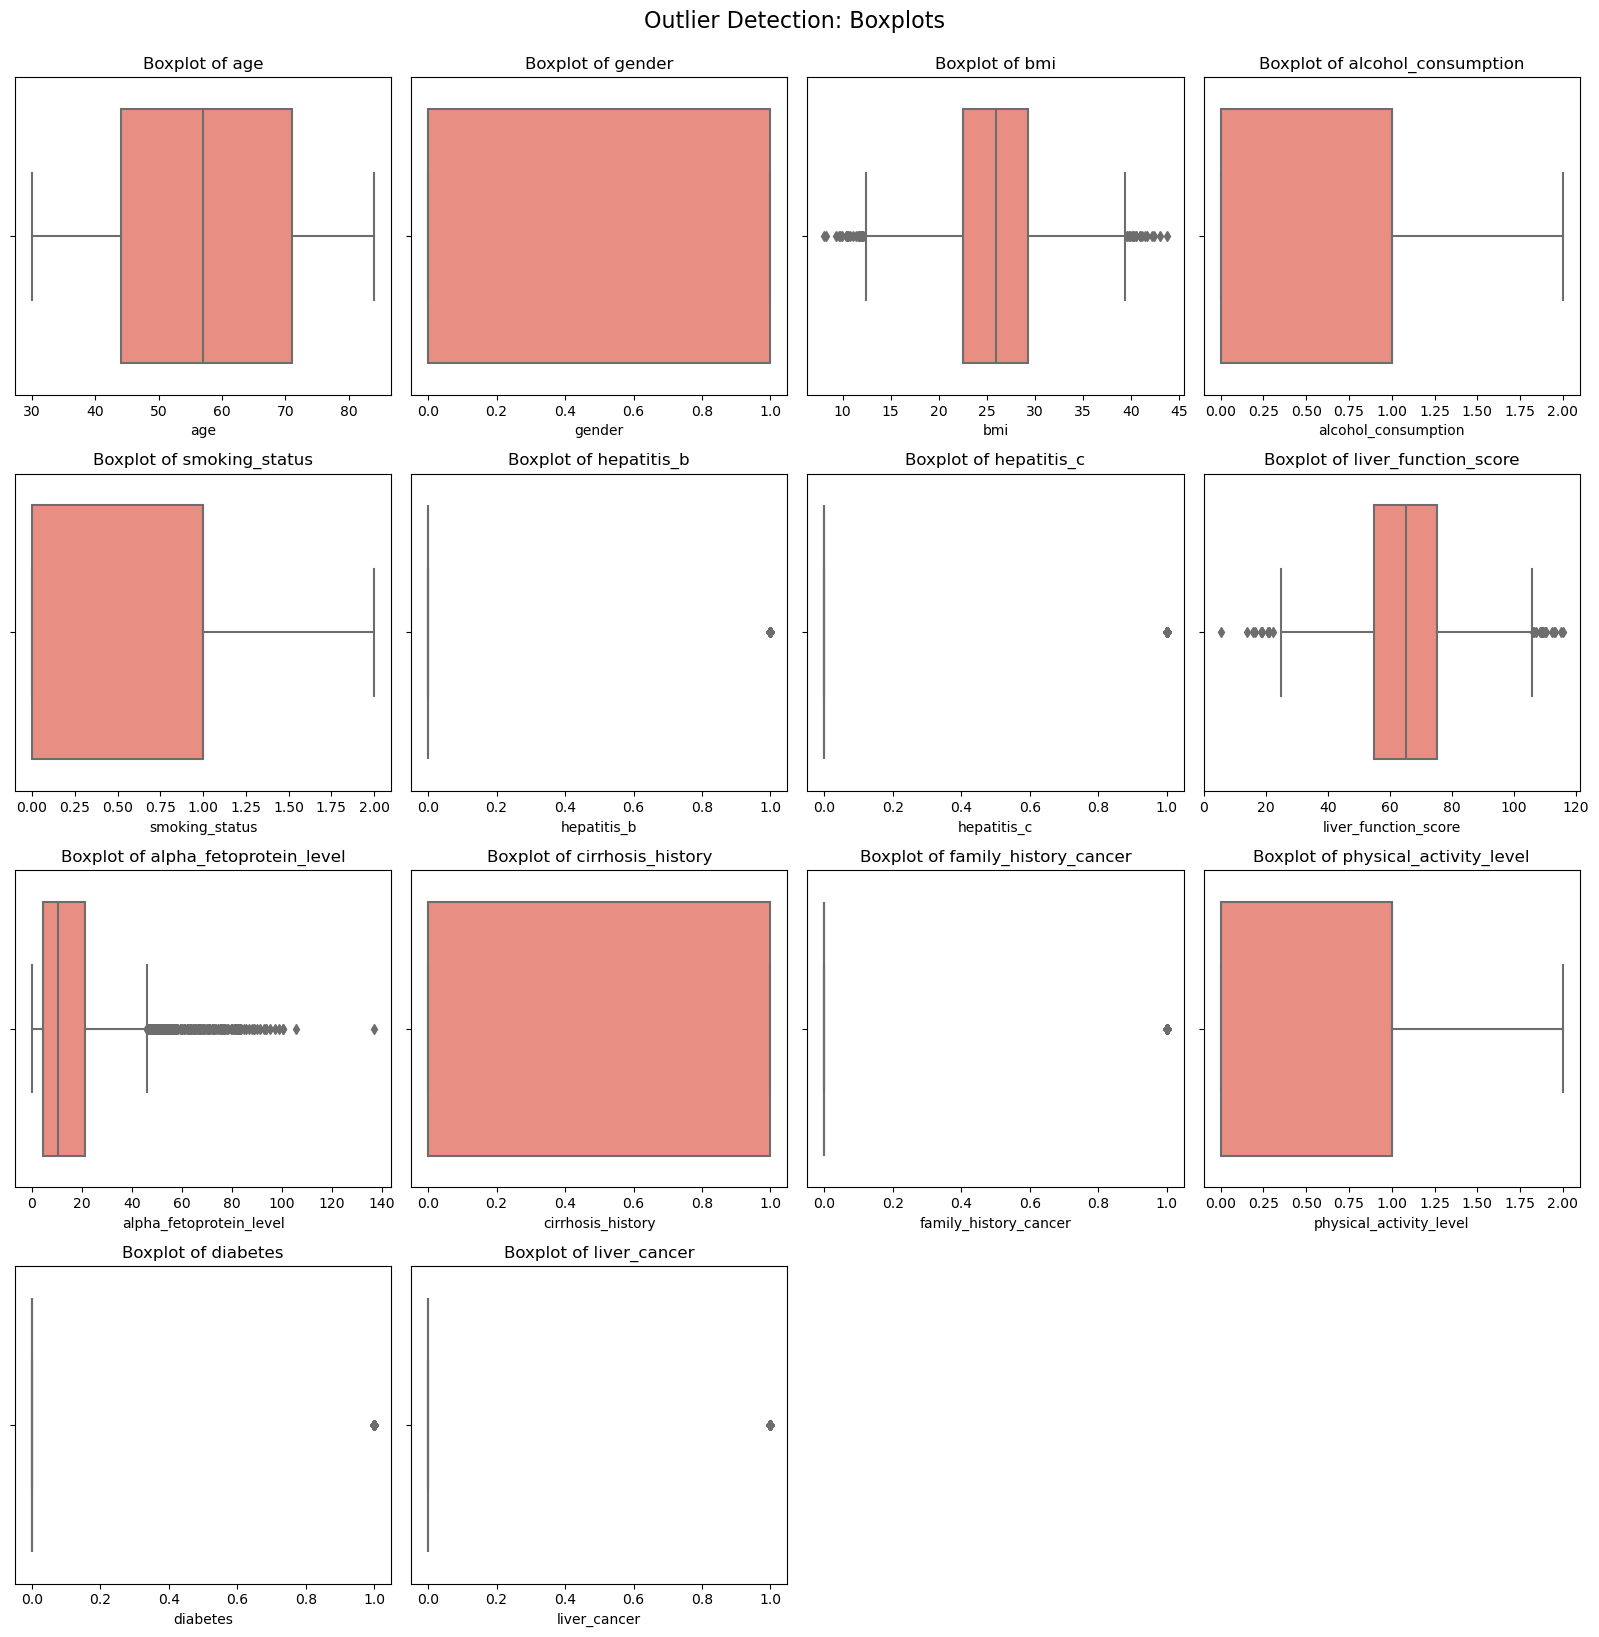


Outliers detected using IQR method:
age: 0 outliers
gender: 0 outliers
bmi: 43 outliers
alcohol_consumption: 0 outliers
smoking_status: 0 outliers
hepatitis_b: 756 outliers
hepatitis_c: 479 outliers
liver_function_score: 28 outliers
alpha_fetoprotein_level: 237 outliers
cirrhosis_history: 0 outliers
family_history_cancer: 1207 outliers
physical_activity_level: 0 outliers
diabetes: 996 outliers
liver_cancer: 1089 outliers

Outliers detected using Z-score method:
age: 0 outliers
gender: 0 outliers
bmi: 16 outliers
alcohol_consumption: 0 outliers
smoking_status: 0 outliers
hepatitis_b: 0 outliers
hepatitis_c: 479 outliers
liver_function_score: 14 outliers
alpha_fetoprotein_level: 97 outliers
cirrhosis_history: 0 outliers
family_history_cancer: 0 outliers
physical_activity_level: 0 outliers
diabetes: 0 outliers
liver_cancer: 0 outliers


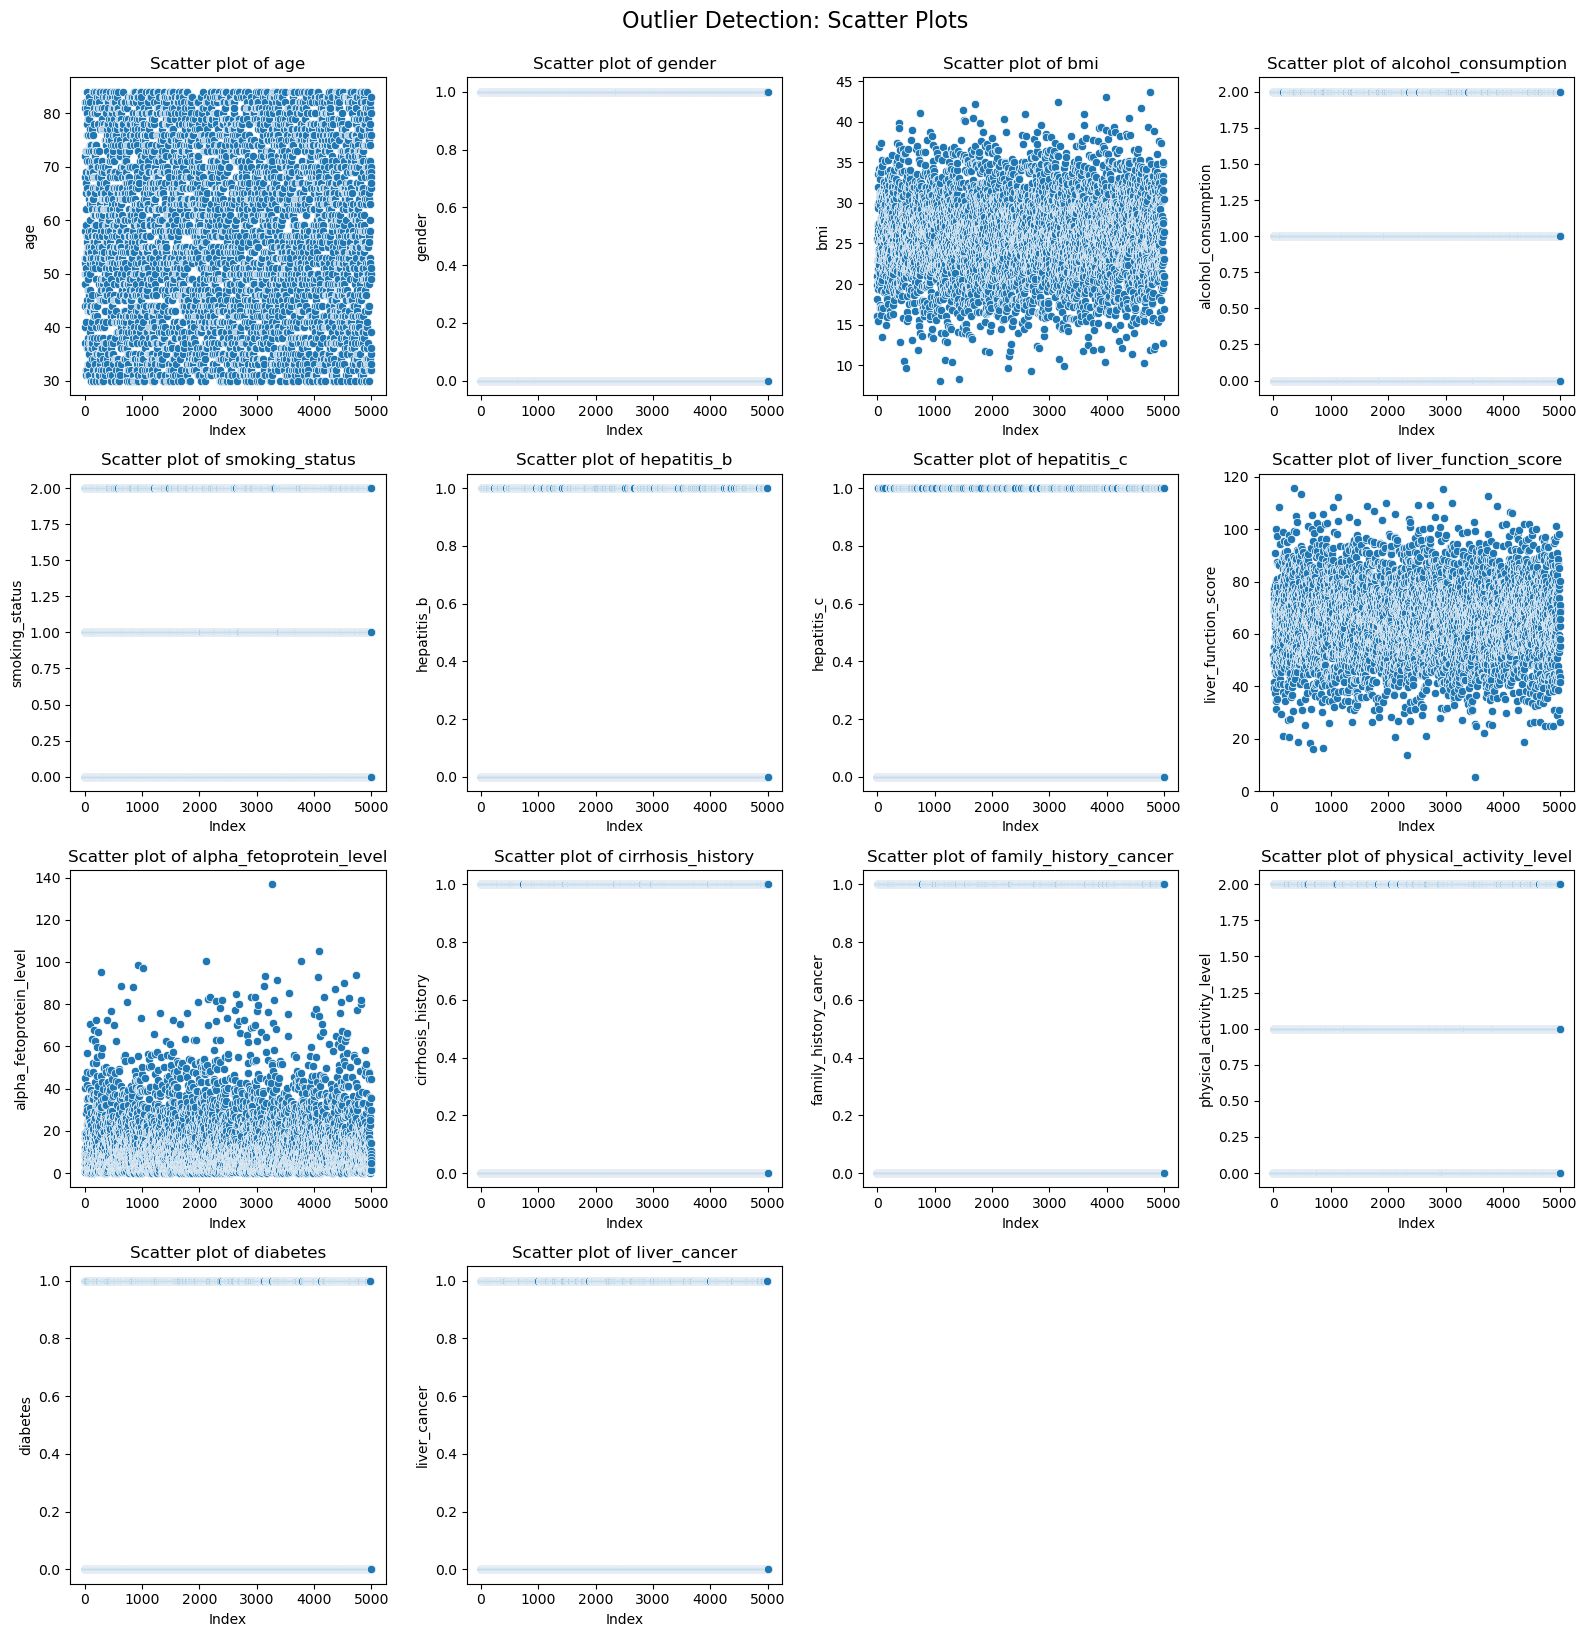

In [14]:
numerical_cols = df.select_dtypes(include=[np.number]).columns
n_cols = len(numerical_cols)

# Dynamically calculate grid size
n_columns_plot = 4
n_rows_plot = math.ceil(n_cols / n_columns_plot)

# -------------------------
# Step 1: Boxplots
# -------------------------
plt.figure(figsize=(16, 4 * n_rows_plot))

for i, col in enumerate(numerical_cols, 1):
    plt.subplot(n_rows_plot, n_columns_plot, i)
    sns.boxplot(x=df[col], color='salmon')
    plt.title(f'Boxplot of {col}')

plt.tight_layout()
plt.suptitle("Outlier Detection: Boxplots", fontsize=16, y=1.02)
plt.show()

# -------------------------
# Step 2: IQR Method
# -------------------------
outliers_iqr = {}

for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers_iqr[col] = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

print("\nOutliers detected using IQR method:")
for col, outliers in outliers_iqr.items():
    print(f"{col}: {len(outliers)} outliers")

# -------------------------
# Step 3: Z-Score Method (FIXED)
# -------------------------
outliers_zscore = {}
z_threshold = 3

for col in numerical_cols:
    z_scores = np.abs(stats.zscore(df[col], nan_policy='omit'))
    outliers_zscore[col] = df[z_scores > z_threshold]

print("\nOutliers detected using Z-score method:")
for col, outliers in outliers_zscore.items():
    print(f"{col}: {len(outliers)} outliers")

# -------------------------
# Step 4: Scatter Plots
# -------------------------
plt.figure(figsize=(16, 4 * n_rows_plot))

for i, col in enumerate(numerical_cols, 1):
    plt.subplot(n_rows_plot, n_columns_plot, i)
    sns.scatterplot(x=df.index, y=df[col])
    plt.title(f'Scatter plot of {col}')
    plt.xlabel('Index')
    plt.ylabel(col)

plt.tight_layout()
plt.suptitle("Outlier Detection: Scatter Plots", fontsize=16, y=1.02)
plt.show()

In [15]:
# Handling outliers by Transformation (log transformation for BMI)
# apply log transformation for BMI  to reduce skewness
df['bmi'] =  np.log1p(df['bmi']) # Log transform to reduce the impact of extreme values


In [16]:
# Cap outliers in 'liver_cancer' using the 95th percentile
upper_limit = df['liver_cancer'].quantile(0.95)
lower_limit = df['liver_cancer'].quantile(0.05)
df['liver_cancer'] = np.clip(df['liver_cancer'], lower_limit, upper_limit)


In [17]:
# Capping outliers for 'family_history_cancer'
upper_limit_family_history = df['family_history_cancer'].quantile(0.95)
lower_limit_family_history = df['family_history_cancer'].quantile(0.05)
df['family_history_cancer'] = np.clip(df['family_history_cancer'], lower_limit_family_history, upper_limit_family_history)

# Data Preprocessing for Liver Cancer Prediction

In this phase of the project ,we prepare the dataset to build and train machine learning models. The steps involved in the preprocessing ensure that the data is clean , standdardized and properly formatted for model consumption. Below are the key steps involved in our data preprocessing:

In [18]:
# Assuming 'data' is the dataset, and 'liver_cancer' is the target variable.
# Step 1: Split the Data into Training and Testing Sets (80-20 split)
X = df.drop('liver_cancer', axis=1)  # Features (X)
y = df['liver_cancer']  # Target variable (y)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [19]:
# Step 2: Feature Scaling (Standardization)
# Separate numerical and categorical columns
numerical_cols = X.select_dtypes(include=[float, int]).columns
categorical_cols = X.select_dtypes(include=[object]).columns

# Initialize the scaler for numerical features
scaler = StandardScaler()

# Fit and transform the scaler on the training data (only on numerical columns)
X_train_scaled = X_train[numerical_cols].copy()
X_train_scaled = scaler.fit_transform(X_train_scaled)

# Apply the same transformation to the test set
X_test_scaled = X_test[numerical_cols].copy()
X_test_scaled = scaler.transform(X_test_scaled)

# Replace the original numerical columns with the scaled ones
X_train[numerical_cols] = X_train_scaled
X_test[numerical_cols] = X_test_scaled

# Step 3: Encoding Categorical Variables (One-Hot Encoding)
# Apply one-hot encoding to categorical variables on both training and test sets
X_train_encoded = pd.get_dummies(X_train, columns=categorical_cols, drop_first=True)
X_test_encoded = pd.get_dummies(X_test, columns=categorical_cols, drop_first=True)

# Step 4: Feature Selection using SelectKBest (ANOVA F-statistic)
# Apply feature selection to the encoded training data
selector = SelectKBest(score_func=f_classif, k=10)
X_train_selected = selector.fit_transform(X_train_encoded, y_train)

# Apply feature selection to the encoded test data (transform only)
X_test_selected = selector.transform(X_test_encoded)

# Get the names of the selected features
selected_features = X_train_encoded.columns[selector.get_support()]
print("Selected Features:", selected_features)

# Check the shape of the resulting sets
print(f"Training set features shape: {X_train_selected.shape}")
print(f"Testing set features shape: {X_test_selected.shape}")

Selected Features: Index(['age', 'bmi', 'alcohol_consumption', 'smoking_status', 'hepatitis_b',
       'hepatitis_c', 'alpha_fetoprotein_level', 'cirrhosis_history',
       'family_history_cancer', 'diabetes'],
      dtype='object')
Training set features shape: (4000, 10)
Testing set features shape: (1000, 10)


# Evaluation of Machine Learning Models for Liver Cancer Prediction

In this section, we assess the performance of five machine learning classification models developed to predict liver cancer. Each model was trained using the preprocessed dataset, and their predictive capabilities were compared using several key evaluation metrics.

## Models Evaluated

- **Logistic Regression**
- **Random Forest Classifier**
- **Support Vector Machine (SVM)**
- **K-Nearest Neighbors (KNN)**
- **XGBoost Classifier**

## Evaluation Metrics

To measure the effectiveness of each model, we used the following performance metrics:

- **Accuracy**: The proportion of total predictions that were correctly classified.
- **Precision**: The percentage of predicted positive cases that are actually positive.
- **Recall**: The percentage of actual positive cases that were correctly identified by the model.
- **F1-Score**: The harmonic mean of precision and recall, providing a balance between the two metrics.

Based on the results obtained from these metrics, we can compare the performance of the different models. This evaluation helps identify the most suitable model for further optimization and potential deployment in a liver cancer prediction system.

In [20]:
# Define models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(),
    "Support Vector Machine": SVC(),
    "K-Nearest Neighbors": KNeighborsClassifier(),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss')
}

# Dictionary to store the results
results = {}

# Fit and evaluate each model
for model_name, model in models.items():
    
    # Train the model
    model.fit(X_train_selected, y_train)
    
    # Predict
    y_pred = model.predict(X_test_selected)
    
    # Evaluation
    accuracy = accuracy_score(y_test, y_pred)
    class_report = classification_report(y_test, y_pred, output_dict=True)

    results[model_name] = {
        "accuracy": accuracy,
        "precision": class_report["weighted avg"]["precision"],
        "recall": class_report["weighted avg"]["recall"],
        "f1_score": class_report["weighted avg"]["f1-score"]
    }

    print(f"--- {model_name} ---")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {class_report['weighted avg']['precision']:.4f}")
    print(f"Recall: {class_report['weighted avg']['recall']:.4f}")
    print(f"F1 Score: {class_report['weighted avg']['f1-score']:.4f}")
    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    print("\n")

--- Logistic Regression ---
Accuracy: 0.8770
Precision: 0.8722
Recall: 0.8770
F1 Score: 0.8719

Confusion Matrix:
[[730  38]
 [ 85 147]]


--- Random Forest ---
Accuracy: 0.9090
Precision: 0.9078
Recall: 0.9090
F1 Score: 0.9048

Confusion Matrix:
[[748  20]
 [ 71 161]]


--- Support Vector Machine ---
Accuracy: 0.8980
Precision: 0.8952
Recall: 0.8980
F1 Score: 0.8941

Confusion Matrix:
[[739  29]
 [ 73 159]]


--- K-Nearest Neighbors ---
Accuracy: 0.8710
Precision: 0.8659
Recall: 0.8710
F1 Score: 0.8637

Confusion Matrix:
[[734  34]
 [ 95 137]]


--- XGBoost ---
Accuracy: 0.9320
Precision: 0.9311
Recall: 0.9320
F1 Score: 0.9302

Confusion Matrix:
[[750  18]
 [ 50 182]]




C:\Users\lamin\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [12:02:37] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [21]:
results_df = pd.DataFrame(results).T
results_df

,accuracy,precision,recall,f1_score
Logistic Regression,0.877,0.872248,0.877,0.871894
Random Forest,0.909,0.907786,0.909,0.904844
Support Vector Machine,0.898,0.895168,0.898,0.894077
K-Nearest Neighbors,0.871,0.865862,0.871,0.863701
XGBoost,0.932,0.931120,0.932,0.930175


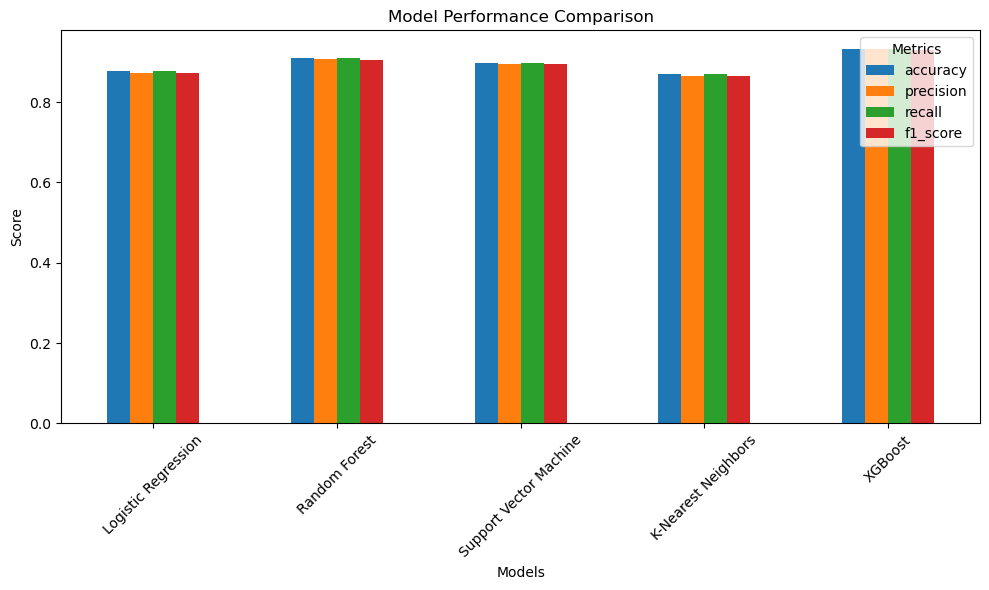

In [22]:
results_df.plot(kind='bar', figsize=(10,6))

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xlabel("Models")
plt.xticks(rotation=45)
plt.legend(title="Metrics")
plt.tight_layout()

plt.show()

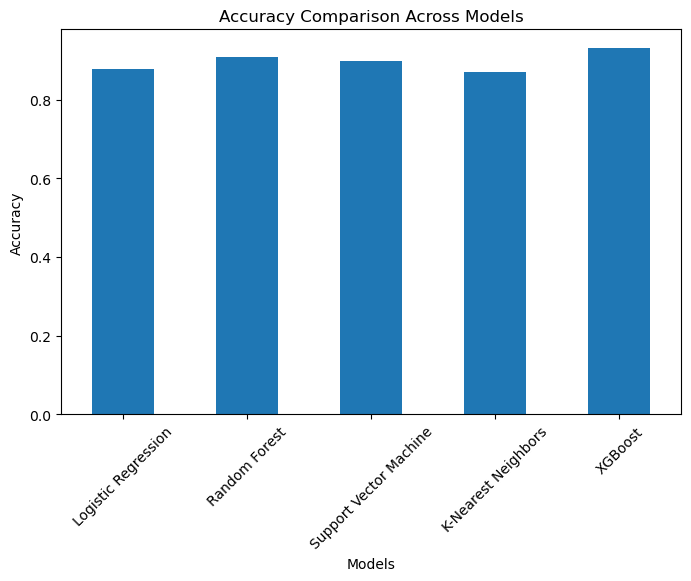

In [23]:
# Accuracy
results_df['accuracy'].plot(kind='bar', figsize=(8,5))

plt.title("Accuracy Comparison Across Models")
plt.ylabel("Accuracy")
plt.xlabel("Models")
plt.xticks(rotation=45)

plt.show()

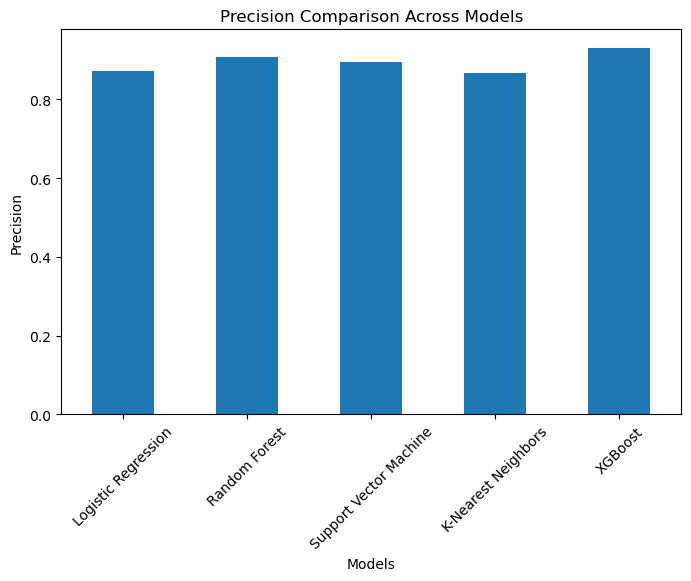

In [24]:
# Precision Plot
results_df['precision'].plot(kind='bar', figsize=(8,5))

plt.title("Precision Comparison Across Models")
plt.ylabel("Precision")
plt.xlabel("Models")
plt.xticks(rotation=45)

plt.show()

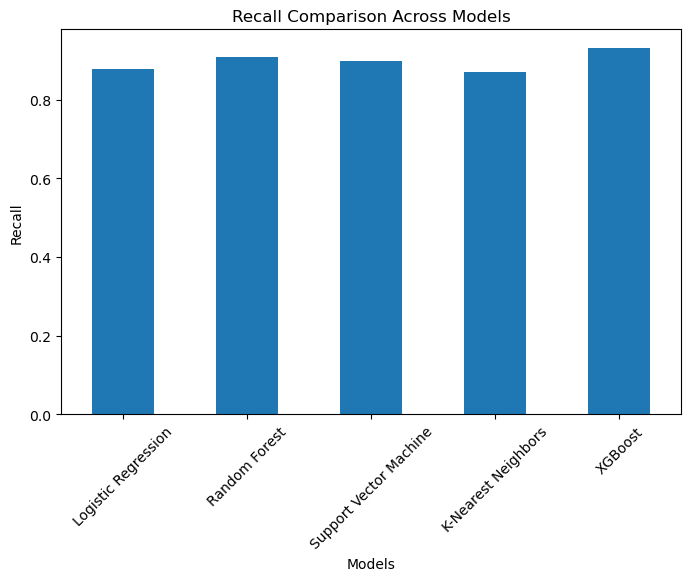

In [25]:
# Recall Plot
results_df['recall'].plot(kind='bar', figsize=(8,5))

plt.title("Recall Comparison Across Models")
plt.ylabel("Recall")
plt.xlabel("Models")
plt.xticks(rotation=45)

plt.show()

In [26]:
# Best Model Visualization
best_model = results_df['accuracy'].idxmax()
best_score = results_df['accuracy'].max()

print("Best Model:", best_model)
print("Best Accuracy:", best_score)

Best Model: XGBoost
Best Accuracy: 0.932
